<table align="center" width=100%>
    <tr>
        <td width="15%">
            <img src="homework.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                    <b> Take-Home <br>(Session 6)
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

#### Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Read the data

Load the csv file and print the first five observations.

In [2]:
# read the data
df_seed = pd.read_csv('seedtype_data.csv')

# display the first five rows of the data
df_seed.head()

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len,Type
0,12.76,13.38,5.073,3.155,4.830,0.0
1,12.13,13.73,5.394,3.745,5.220,0.0
2,14.86,14.67,NaN,3.258,5.351,0.0
3,15.69,14.75,5.527,3.514,5.046,0.0
4,19.94,16.92,6.675,3.763,6.550,1.0


**The data definition is as follows:** <br>

**Area**: Area of the wheat kernel 

**Perimeter**: Perimeter of the wheat kernel

**Kernel_len**: Length of the wheat kernel

**Kernel_width**: Width of the wheat kernel

**Kernelgroove_len**: Length of the wheat kernel groove

**Type**: Type of the wheat seed (0 = Kama Wheat, 1 = Rosa Wheat) (target/dependent variable)

Our objective is to predict whether the wheat seed is of Kama or Rosa type.

### Let's begin with some hands-on practice exercises

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>1. Is there any record where no data have been reported? If yes, do the needful</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [3]:
empty_rows = df_seed.isna().all(axis=1)
num_empty_rows = empty_rows.sum()
print(f"\nNumber of completely empty rows: {num_empty_rows}")


Number of completely empty rows: 3


In [4]:
# Step 3: If such rows exist, drop them from the dataset
if num_empty_rows > 0:
    df_seed_cleaned = df_seed.dropna(how='all')  # Drop rows where all values are NaN
    print("\nRows with all NaN values have been dropped.")
else:
    df_seed_cleaned = df_seed  # No cleaning needed
    print("\nNo completely empty rows found.")

# Step 4: Display the cleaned dataset
print("\nCleaned Dataset:")
print(df_seed_cleaned)


Rows with all NaN values have been dropped.

Cleaned Dataset:
      Area  Perimeter  Kernel_len  Kernel_width  Kernelgroove_len  Type
0    12.76      13.38       5.073         3.155             4.830   0.0
1    12.13      13.73       5.394         3.745             5.220   0.0
2    14.86      14.67         NaN         3.258             5.351   0.0
3    15.69      14.75       5.527         3.514             5.046   0.0
4    19.94      16.92       6.675         3.763             6.550   1.0
..     ...        ...         ...           ...               ...   ...
196  18.30      15.89       5.979         3.755             5.962   1.0
198  12.78      13.57       5.262         3.026             4.782   0.0
199  13.07      13.92       5.472         2.994             5.395   0.0
200  18.55      16.22       6.153         3.674             5.894   1.0
201  13.34      13.95       5.389         3.074             5.307   0.0

[199 rows x 6 columns]


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>2. Use the visualization technique to identify the variables with missing data</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [5]:
# type your code here
df_seed_cleaned.isnull().sum()

Area                0
Perimeter           0
Kernel_len          6
Kernel_width        0
Kernelgroove_len    0
Type                0
dtype: int64

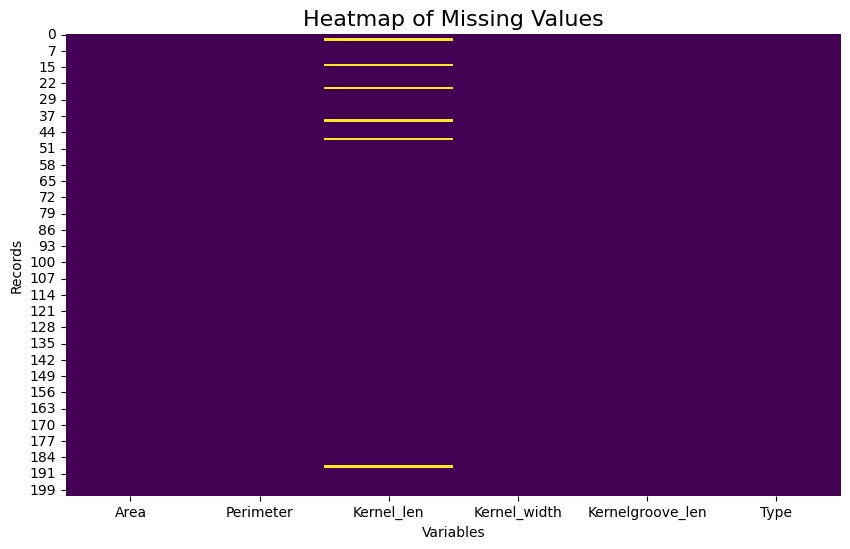

In [6]:
# Heatmap to visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df_seed_cleaned.isnull(), cbar=False, cmap='viridis')  # `isna()` identifies missing values
plt.title("Heatmap of Missing Values", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Records")
plt.show()

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>3. Use the appropriate technique to replace the missing data in the variable representing the length of a wheat kernel
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [7]:
df_seed_cleaned.describe()

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len,Type
count,199.000000,199.000000,193.000000,199.000000,199.000000,199.000000
mean,15.476533,14.792261,5.651036,3.471643,5.445779,0.356784
std,2.504142,1.210241,0.445302,0.305630,0.479849,0.480258
min,12.010000,13.010000,4.899000,2.911000,4.649000,0.000000
25%,13.345000,13.690000,5.267000,3.200000,5.059500,0.000000
50%,14.990000,14.670000,5.554000,3.485000,5.275000,0.000000
75%,17.490000,15.885000,6.006000,3.763000,5.879000,1.000000
max,21.180000,17.250000,6.675000,4.033000,6.550000,1.000000


###### Based on above descriptive statistsics we can observe that most of the variables mean & 50% value are close.
###### Therefore we can derive an inference that there are no outliers in this dataset.
###### But we will visualize all the variables to confirm the same.

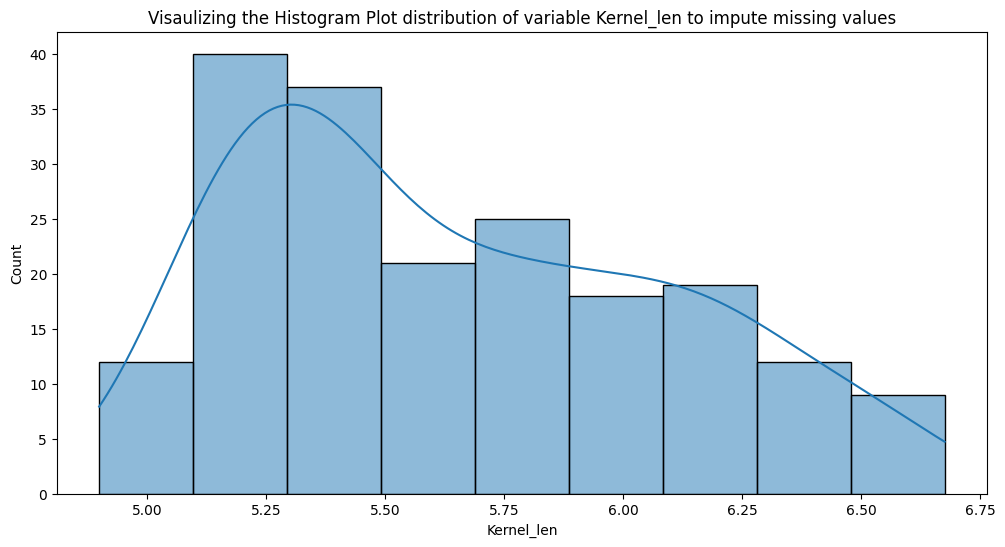

In [8]:
# Visualizing the distribution of Data for Kernel_len variable which has missing values

plt.figure(figsize=(12, 6))
# Creating histplot with kde
sns.histplot(data=df_seed_cleaned, x='Kernel_len', kde=True)
plt.title("Visaulizing the Histogram Plot distribution of variable Kernel_len to impute missing values")
plt.show()

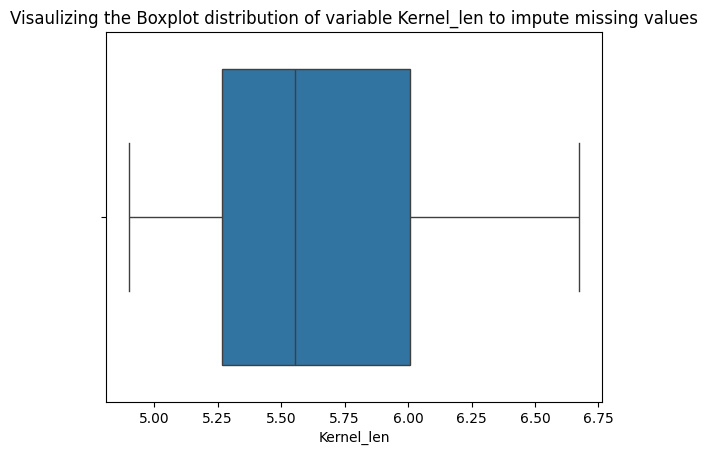

In [9]:
# Creating boxplot 
sns.boxplot(df_seed_cleaned['Kernel_len'], orient='h')

plt.title("Visaulizing the Boxplot distribution of variable Kernel_len to impute missing values")
plt.show()

In [10]:
df_seed_cleaned['Kernel_len'] = df_seed_cleaned['Kernel_len'].fillna(df_seed_cleaned['Kernel_len'].mean())

/var/folders/24/mqmdkwnj6kddqftgh4v56jh00000gn/T/ipykernel_37729/2294472969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seed_cleaned['Kernel_len'] = df_seed_cleaned['Kernel_len'].fillna(df_seed_cleaned['Kernel_len'].mean())


In [11]:
df_seed_cleaned.isnull().sum()

Area                0
Perimeter           0
Kernel_len          0
Kernel_width        0
Kernelgroove_len    0
Type                0
dtype: int64

###### There are no missing values in the dataset.

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>4. Identify the variables containing extreme values and remove such observations, if present
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [12]:
df_seed_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,199.0,15.476533,2.504142,12.010,13.3450,14.990,17.4900,21.180
Perimeter,199.0,14.792261,1.210241,13.010,13.6900,14.670,15.8850,17.250
Kernel_len,199.0,5.651036,0.438504,4.899,5.2785,5.579,5.9895,6.675
Kernel_width,199.0,3.471643,0.305630,2.911,3.2000,3.485,3.7630,4.033
Kernelgroove_len,199.0,5.445779,0.479849,4.649,5.0595,5.275,5.8790,6.550
Type,199.0,0.356784,0.480258,0.000,0.0000,0.000,1.0000,1.000


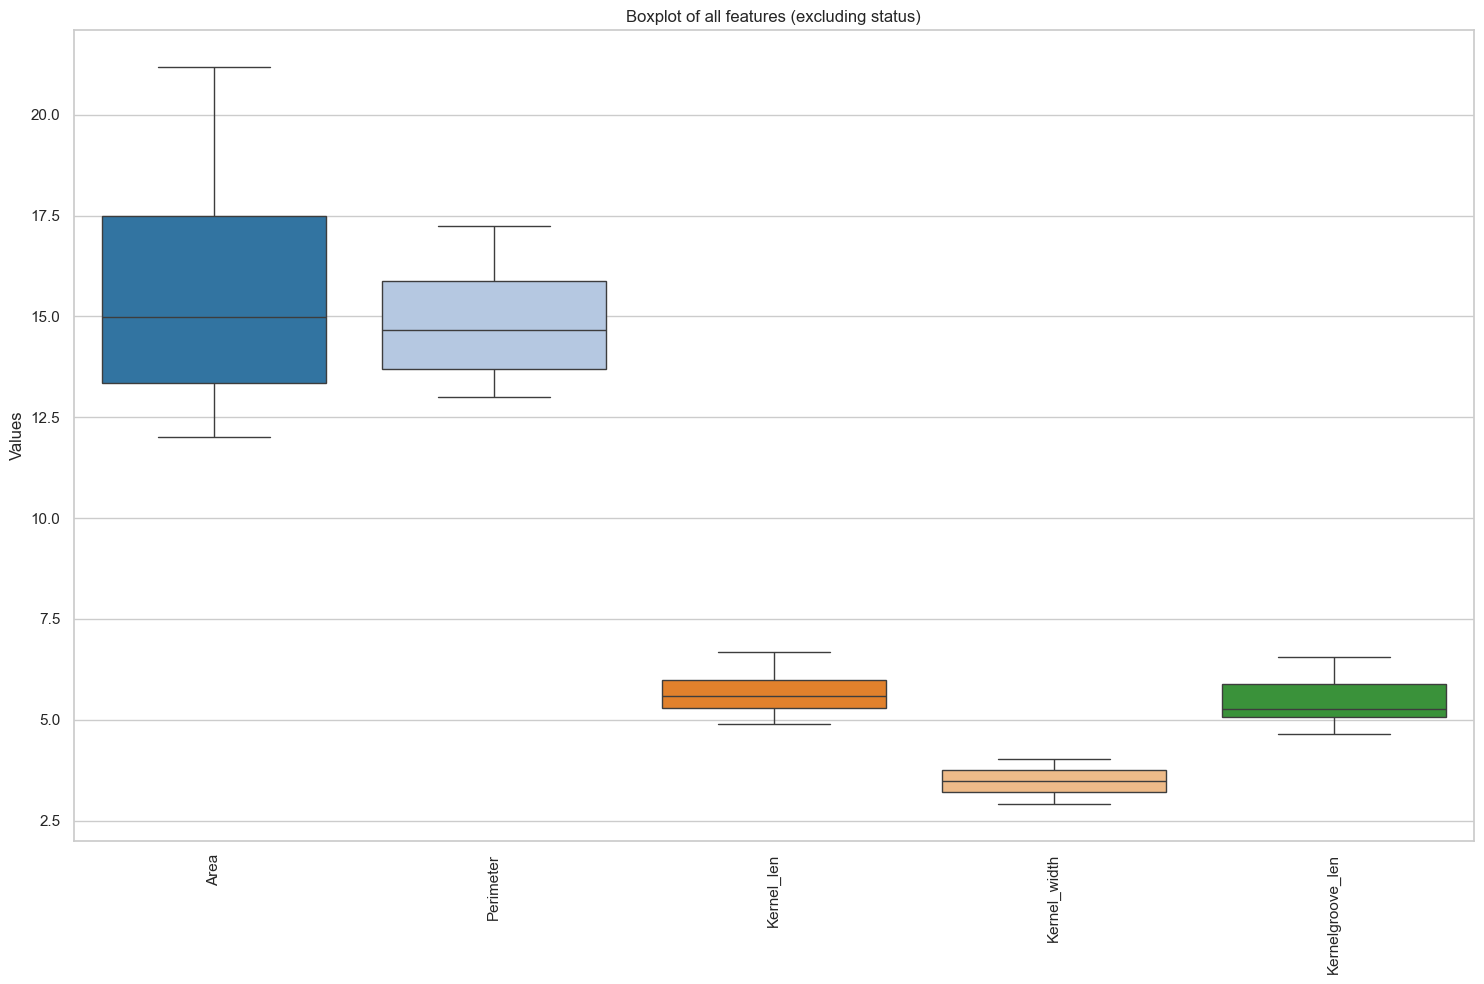

In [13]:
# Visualizing all features for outliers
df_features = df_seed_cleaned.drop(columns=['Type'], errors='ignore')

# Box plot for all variables
sns.set(style="whitegrid")

# Plot boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_features, palette='tab20')
plt.title('Boxplot of all features (excluding status)')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### As per above box plot there are no variables having extreme values (outliers)

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>5. Apply the gradient boosting on 80% of the data with 250 estimators each of maximum depth 2. Also, calculate the precision and sensitivity using the confusion matrix
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [14]:
# Preparing the features & target

X = df_features
y = df_seed_cleaned['Type']

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Create Gradient Boost Model
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=250, max_depth=2, random_state=10)

# Train Model
gb_model.fit(X_train,y_train)

# Make Prediction
y_pred = gb_model.predict(X_test)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Extract precision and sensitivity from confusion matrix
TP = cm[0, 0]  # True Positives
FP = cm[1, 0]  # False Positives
FN = cm[0, 1]  # False Negatives
TN = cm[1, 1]  # True Negatives

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"\nPrecision: {precision:.2f}")
print(f"Sensitivity (Recall): {sensitivity:.2f}")

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        29
         1.0       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[29  0]
 [ 0 11]]

Precision: 1.00
Sensitivity (Recall): 1.00


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>6. Create 80 stumps using AdaBoost and plot the ROC curve along with the AUC score
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

Use the train and test set from Q5.

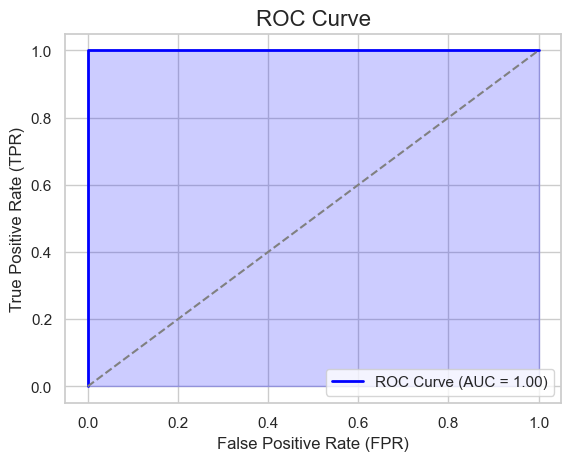

AUC Score: 1.00


In [16]:
# Creating Stumps
from sklearn.tree import DecisionTreeClassifier
stumps = DecisionTreeClassifier(max_depth=1, random_state=10)

# Creating AdaBoost Classifier with 80 stumps
from sklearn.ensemble import AdaBoostClassifier
adaboost = AdaBoostClassifier(
            estimator=stumps,
            n_estimators=80,
            random_state=10
)

# Model Training
adaboost.fit(X_train, y_train)

# Model Metrics via AUC ROC
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate Predicted Probabiblities for Positive Class to be used for ROC Curve
y_pred_proba = adaboost.predict_proba(X_test)[:,1]

# Compute ROC AUC Score & ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')  # Optional: Fill area under the curve
plt.title("ROC Curve", fontsize=16)
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)  # Seaborn-styled grid
plt.show()

# Print AUC Score
print(f"AUC Score: {auc_score:.2f}")



<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>7. Select the optimal maximum depth from the given values for 180 base learners to build the gradient boosting classifier (consider 3-fold cross validation)
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

**Use the given list:**

depth = [2, 3, 4, 5, 6, 7, 8]

Consider the train and test set in Q5.

In [17]:
# Create a Gradient Boosting Model for 180 stumps (base learners)
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=180, random_state=10)
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8]
}

# Grid Search CV for 3-fold cross validation
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

print("Best Accuracy:", grid_search.best_score_)

# Evaluate the Final Model on the Test Set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)


Best Hyperparameters: {'max_depth': 3}
Best Accuracy: 0.9622641509433962
Test Accuracy: 1.0


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>8. Build the XGBoost model with a learning rate of 0.4 and gamma equal to 3. Calculate the accuracy by plotting the confusion matrix
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

#### Build an XGBoost model on a training dataset.

Consider the train and test set in Q5.

Confusion Matrix:
 [[29  0]
 [ 0 11]]
Accuracy Score: 1.0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:28:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


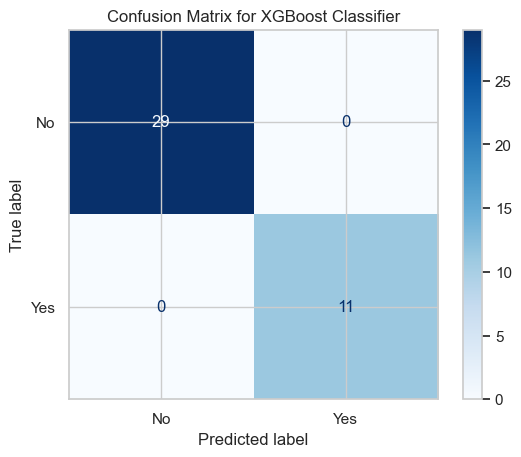

In [22]:
# Create XGBoost Model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
            learning_rate=.04,
            gamma=3,
            random_state=10,
            use_label_encoder=False,
            eval_metric='logloss'
)

# Train the XGBoost Model
xgb_model.fit(X_train,y_train)

# Make Predctions
y_pred = xgb_model.predict(X_test)

# Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test,y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Accuracy Score:", accuracy)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No', 'Yes'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")
plt.show()



<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>9. Use the stacking technique on 70% of the data with the 9-NN and Naive Bayes model as base learners. Consider the Adaboost model as a final estimator. Also, compute the AUC score of the model </b>
                </font>
            </div>
        </td>
    </tr>
</table>

ROC-AUC Score: 0.99


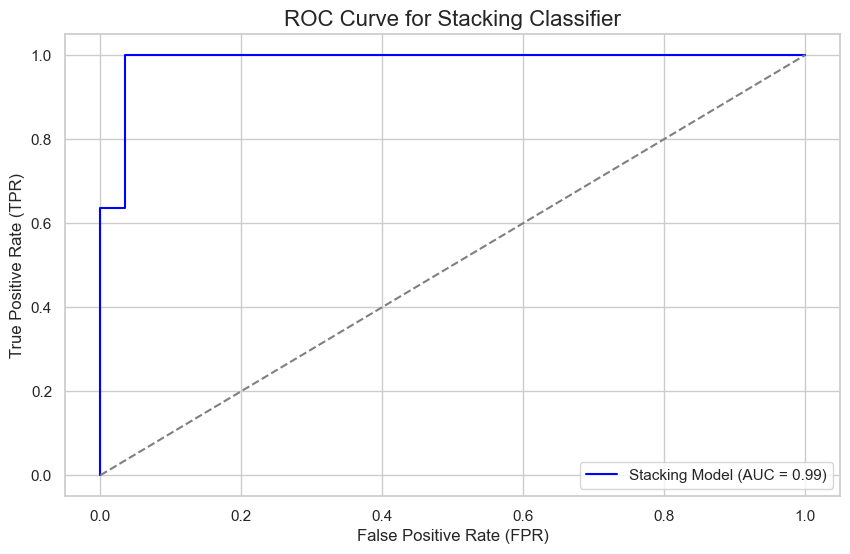

In [31]:
# Importing Libraries for KNN, Naive Bayes, ROC Curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier

# Define Base Learner
knn = KNeighborsClassifier(n_neighbors=9)
nb = GaussianNB()

# Define Final Estmator
adaboost = AdaBoostClassifier(random_state=10)

# Define Stacking Classifier
stacking_model = StackingClassifier(
    estimators=[
        ('knn',knn),
        ('naive_bayes',nb),
    ],
    final_estimator=adaboost,
    cv=5
)

# Train Stacking Classifier
stacking_model.fit(X_train, y_train)

# Make Predictions
y_pred_proba = stacking_model.predict_proba(X_test)[:,1]

# Compute ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.2f}")

# Step 9: Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f"Stacking Model (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random guess curve
plt.title('ROC Curve for Stacking Classifier', fontsize=16)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()





<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>10. Use the base learners in Q9 and build a stacking model with the XGBoost as final estimator. Compute the AUC score of the model and compare it with the result of Q9 
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

ROC-AUC Score (Stacking with XGBoost as Final Estimator): 0.99


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [15:53:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


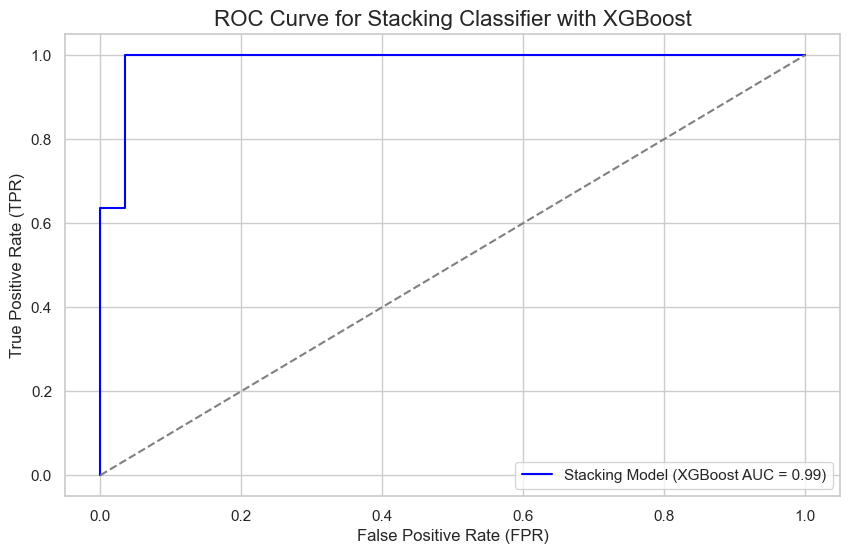

In [33]:
# Final Estimator: XGBoost
xgb_final = XGBClassifier(
    random_state=42,
    use_label_encoder=False,  # Suppress warnings
    eval_metric='logloss'  # Set evaluation metric explicitly
)


# Define Stacking Model with XGBoost as Final Estimator
stacking_model_xgb = StackingClassifier(
    estimators=[
        ('knn', knn),            # Base learner 1: k-NN
        ('naive_bayes', nb)      # Base learner 2: Naive Bayes
    ],
    final_estimator=xgb_final,   # Final Estimator: XGBoost
    cv=5  # 5-Fold Cross Validation
)

# Train Stacking Model
stacking_model_xgb.fit(X_train, y_train)

# Predict Probabilities for Test Set
y_pred_proba_xgb = stacking_model_xgb.predict_proba(X_test)[:, 1]  # Positive class probabilities

# Compute the AUC Score
auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC-AUC Score (Stacking with XGBoost as Final Estimator): {auc_score_xgb:.2f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f"Stacking Model (XGBoost AUC = {auc_score_xgb:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random guess line
plt.title('ROC Curve for Stacking Classifier with XGBoost', fontsize=16)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()